In [120]:

import pandas as pd
import matplotlib as plt
import seaborn as sns
import numpy as np
import pickle

# Загрузка и знакомство с данными

In [121]:

df = pd.read_csv('/home/mainuser/savvin_iis/data/car_data.csv')


In [122]:
df.head(10)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [123]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [124]:
df=df.rename(columns={'Present_Price':'Target_Present_Price'})


In [125]:
df['Car_Name'] = df['Car_Name'].astype('category')
df['Fuel_Type'] = df['Fuel_Type'].astype('category')
df['Transmission'] = df['Transmission'].astype('category')
df['Selling_type'] = df['Selling_type'].astype('category')

In [126]:
df['Owner'] = df['Owner'].astype('int8')
df['Year'] = df['Year'].astype('int16')
df['Driven_kms'] = df['Driven_kms'].astype('int32')


In [127]:

df['Selling_Price'] = df['Selling_Price'].astype('float16')
df['Target_Present_Price'] = df['Target_Present_Price'].astype('float16')


In [128]:
df.describe()

,Year,Selling_Price,Target_Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.660156,7.628906,36947.205980,0.043189
std,2.891554,5.082031,8.640625,38886.883882,0.247915
min,2003.000000,0.099976,0.320068,500.000000,0.000000
25%,2012.000000,0.899902,1.200195,15000.000000,0.000000
50%,2014.000000,3.599609,6.398438,32000.000000,0.000000
75%,2016.000000,6.000000,9.898438,48767.000000,0.000000
max,2018.000000,35.000000,92.625000,500000.000000,3.000000


In [129]:
df=df.drop(columns=['Owner'])

In [130]:
cat_features = df.select_dtypes(include=['category']).columns.to_list()
cat_features

['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']

In [131]:
num_features = df.select_dtypes(include=['number']).columns.to_list()
num_features

['Year', 'Selling_Price', 'Target_Present_Price', 'Driven_kms']

In [132]:
df.info(show_counts=True) # уменьшили размер в 3 раза (5.1 Kб против 16.9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Car_Name              301 non-null    category
 1   Year                  301 non-null    int16   
 2   Selling_Price         301 non-null    float16 
 3   Target_Present_Price  301 non-null    float16 
 4   Driven_kms            301 non-null    int32   
 5   Fuel_Type             301 non-null    category
 6   Selling_type          301 non-null    category
 7   Transmission          301 non-null    category
dtypes: category(4), float16(2), int16(1), int32(1)
memory usage: 7.4 KB


In [133]:
for cat in cat_features:
    print(f'{cat} - numer of unique = {df[cat].nunique()}')

Car_Name - numer of unique = 98
Fuel_Type - numer of unique = 3
Selling_type - numer of unique = 2
Transmission - numer of unique = 2


In [134]:
for col in cat_features:
    print(f'Unique categories in {col}: {df[col].value_counts()}')

Unique categories in Car_Name: Car_Name
city             26
corolla altis    16
verna            14
fortuner         11
brio             10
                 ..
ignis             1
omni              1
land cruiser      1
s cross           1
vitara brezza     1
Name: count, Length: 98, dtype: int64
Unique categories in Fuel_Type: Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Unique categories in Selling_type: Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64
Unique categories in Transmission: Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


# Анализ признаков для модели

## graphs

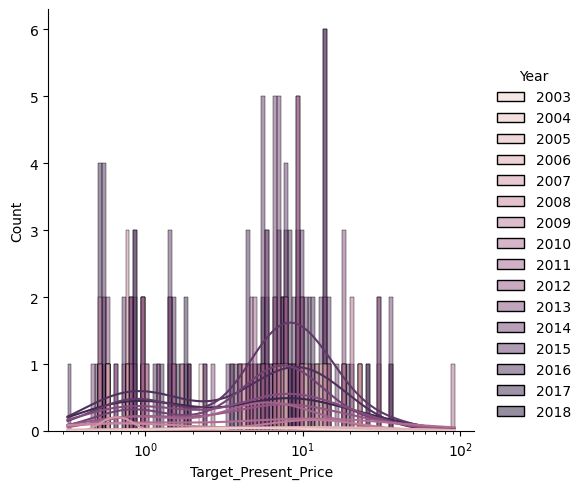

In [135]:
#Построение гистограммы, отражающей зависимость текущей цены от года
sns.displot(df, x='Target_Present_Price', bins=100, hue='Year', kde=True, log_scale=True)

По гистограмме видно, что наибольшее число автомобилей соответствуют году 2015, и цена выше среднего, большинство автомобилей соответсвуют цене, соовтетствующей 10, меньше - цене до 10, есть один автомобиль по очень низкой цене и один по очень высокой - 100



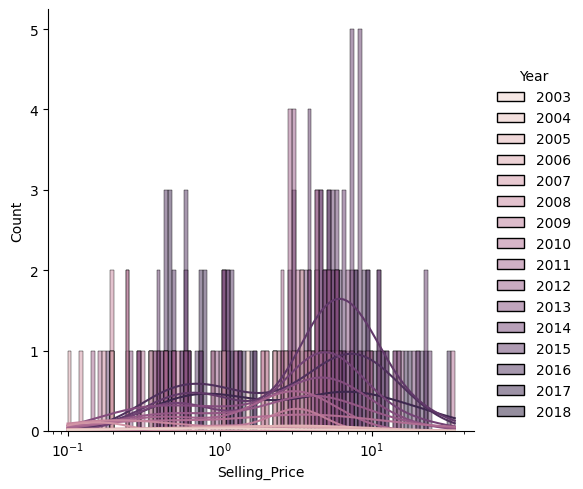

In [136]:
#Такая же гистограмма, но для цены продажи
sns.displot(df, x='Selling_Price', bins=100, hue='Year', kde=True, log_scale=True)

Общий ценовой диапазон смещён в низкую сторону



<Axes: >

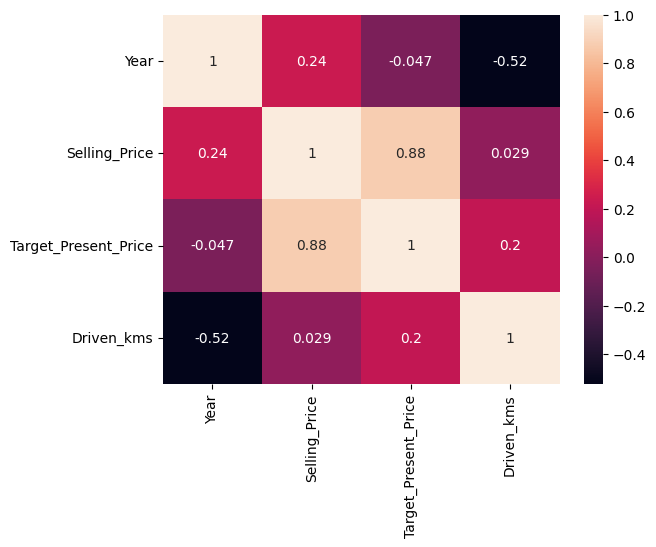

In [137]:
#С помощью heatmap можно узнать корреляцию признаков
feature_correlation = df[num_features].corr()
sns.heatmap(feature_correlation, annot=True)

Видно, что корреляция очень низкая, только цена продажи и текущая цена коррелируют, однако было бы странно, если было бы по другому



<Axes: xlabel='Year', ylabel='Target_Present_Price'>

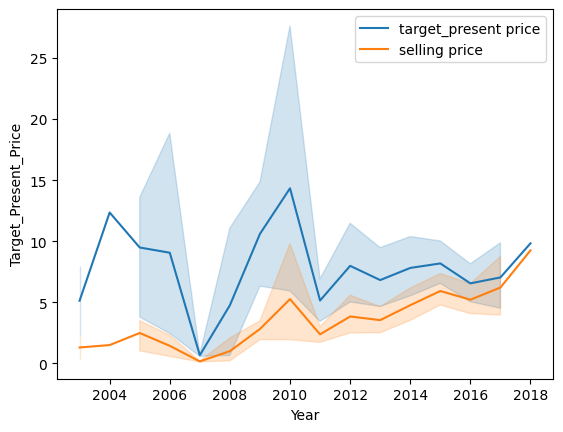

In [138]:
#Линейный график, отражающий зависимость цены продажи и текущей цены от года
sns.lineplot(df,x='Year',y='Target_Present_Price', label='target_present price')
sns.lineplot(df,x='Year',y='Selling_Price', label='selling price')

<Axes: xlabel='Driven_kms', ylabel='Target_Present_Price'>

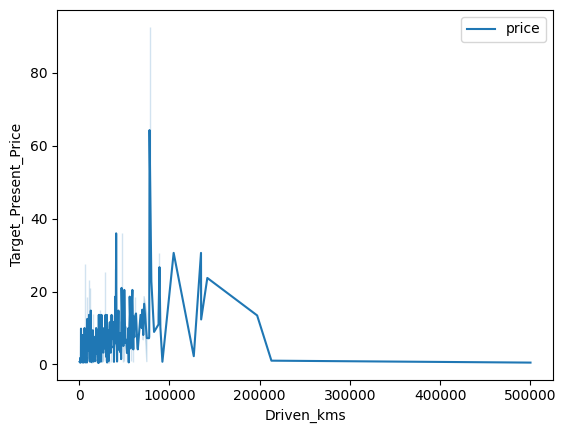

In [139]:
#Линейный график зависимости  теущей цены от пройденных километров 
sns.lineplot(df,x='Driven_kms',y='Target_Present_Price', label='price')

С увеличением пройденных километров цена сначала увеличивается до 100000 км, затем уменьшается, большинство автомобилей имеют пройденное растояние меньше, чем 100000 км

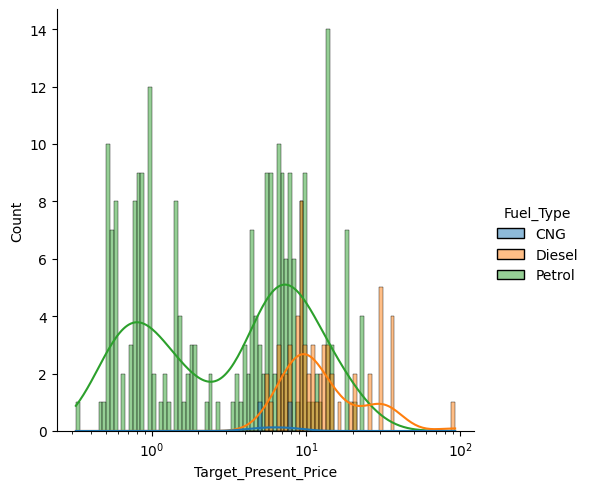

In [140]:
#гистограмма зависимости цены от типа топлива
sns.displot(df, x='Target_Present_Price', bins=100, hue='Fuel_Type', kde=True, log_scale=True)

По гистограмме видно, что большинство имеют бензиновй тип топлива, второй по популярности -дизельное топливо, третье и очень малочисленное - CNG. По графику видно, что автомобили на бензине дешевле, чем автомобили на дизельном топливе

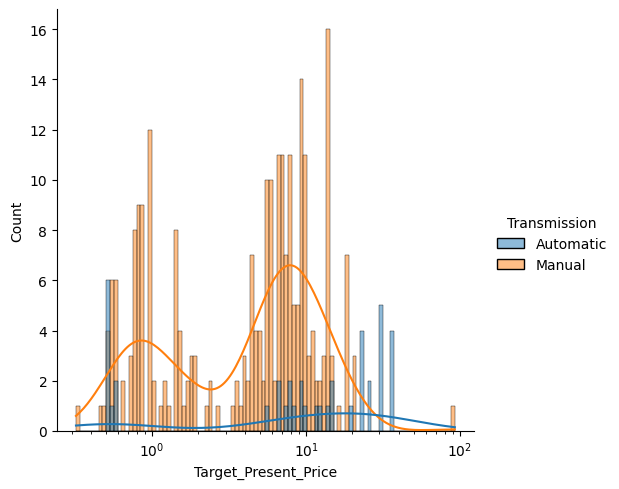

In [141]:

#Гистограмма зависимости цены от типа коробки передач
sns.displot(df, x='Target_Present_Price', bins=100, hue='Transmission', kde=True, log_scale=True)

Подавляющее большинство - механическая, автомобили на автомате есть как дешёвые, так и дороже, чем на механике, всё так же присутствует один невероятно дорогой автомобиль на механике

# Групповые операции

In [142]:
def flat_index(df_stats): 
    df_stats.columns = df_stats.columns.get_level_values(0) + '_' +  df_stats.columns.get_level_values(1) 
    df_stats.columns = df_stats.columns.to_flat_index() 
    df_stats.reset_index(inplace=True) 
    return df_stats

In [143]:
#Получаем таблицу, содержащую средние и отклонения по годам
aggregated_df = df[num_features].groupby(by='Year').agg(['mean', 'std'])
aggregated_df = flat_index(aggregated_df)
aggregated_df 

,Year,Selling_Price_mean,Selling_Price_std,Target_Present_Price_mean,Target_Present_Price_std,Driven_kms_mean,Driven_kms_std
0,2003,1.300049,1.343434,5.129883,4.031337,94500.000000,45961.940777
1,2004,1.500000,NaN,12.351562,NaN,135154.000000,NaN
2,2005,2.487488,1.565491,9.486206,6.153806,104294.000000,63559.476692
3,2006,1.437347,1.081137,9.058594,10.175851,87422.250000,40295.305950
4,2007,0.159973,0.056537,0.665039,0.120153,51000.000000,2828.427125
5,2008,1.002877,1.471779,4.759556,8.305253,112128.571429,173231.489769
6,2009,2.816650,1.085745,10.601562,5.902264,67820.500000,16201.723411
7,2010,5.262606,8.766931,14.332877,23.118814,60014.066667,45429.155164
8,2011,2.375251,1.477055,5.147795,3.927056,40327.368421,23467.977897
9,2012,3.841192,3.942804,7.984502,8.517218,43798.217391,25502.573966


## lineplot

<Axes: xlabel='Year', ylabel='Selling_Price_mean'>

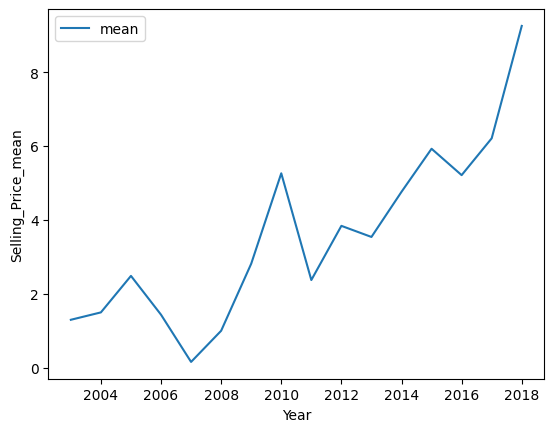

In [144]:

#Линейный график, отражающий зависимость цены продажи от года
sns.lineplot(aggregated_df,x='Year',y='Selling_Price_mean', label='mean')


Чем новее авто, тем оно дороже



<Axes: xlabel='Year', ylabel='Target_Present_Price_mean'>

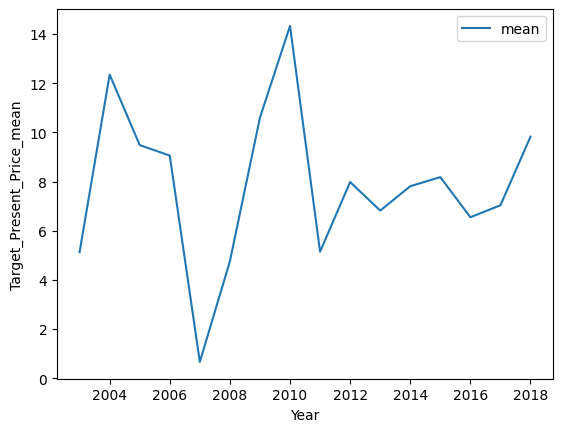

In [145]:
#Линейный график, отражающий зависимость цены продажи от года
sns.lineplot(aggregated_df,x='Year',y='Target_Present_Price_mean', label='mean')

Текущая цена на авто самая низкая на авто 2007 года, самая высокая в 2010



## subplots

/tmp/ipykernel_16094/2934670305.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aggregated_df1 = df[num_features+['Selling_type']].groupby(by='Selling_type').agg(['mean', 'std'])


<Axes: xlabel='Selling_type', ylabel='Selling_Price_mean'>

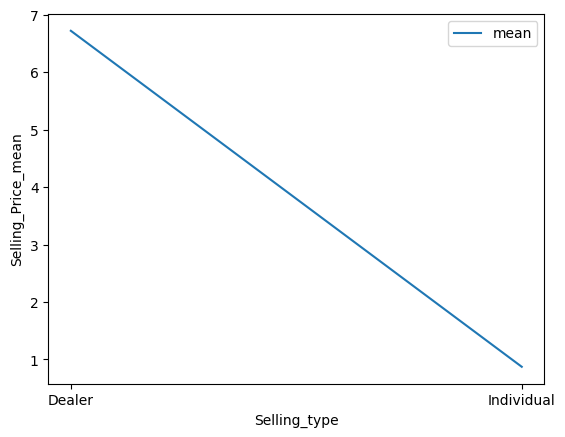

In [146]:
aggregated_df1 = df[num_features+['Selling_type']].groupby(by='Selling_type').agg(['mean', 'std'])
aggregated_df1 = flat_index(aggregated_df1)
aggregated_df1 
sns.lineplot(aggregated_df1,x='Selling_type',y='Selling_Price_mean', label='mean')


Данный график показывает, что у дилеров дороже, чем у частных продавцов в 7 раз



# Bokeh
https://bokeh.org/

In [147]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource,  HoverTool, Legend
from bokeh.io import output_notebook 
output_notebook()

Loading BokehJS ...

In [148]:
source = ColumnDataSource(data=df.sample(frac=1))
p = figure(width=1000)
p.scatter(source=source, x='Year', y='Target_Present_Price' )
hover = HoverTool(tooltips=[('Year ', '@Year'),
                              ('Driven_kms', '@Driven_kms'),
                              ('Target_Present_Price','@Target_Present_Price')])

p.add_tools(hover)
show(p)

# Save clean dataset

In [149]:
# Сохраняем обработанный датафрейм, чтобы на следующих этапах не проводить повторно ту же обработку.
# Лучше сохранить в pickle формате, чтобы сохранились все типы данных, в т.ч. category
df.to_pickle('~/savvin_iis/data/clean_data.pkl')

In [150]:
# Считать можно так:
df = pd.read_pickle('~/savvin_iis/data/clean_data.pkl')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Car_Name              301 non-null    category
 1   Year                  301 non-null    int16   
 2   Selling_Price         301 non-null    float16 
 3   Target_Present_Price  301 non-null    float16 
 4   Driven_kms            301 non-null    int32   
 5   Fuel_Type             301 non-null    category
 6   Selling_type          301 non-null    category
 7   Transmission          301 non-null    category
dtypes: category(4), float16(2), int16(1), int32(1)
memory usage: 5.1 KB


# Выводы после EDA

Выводы, полученные в ходе анализа:
* перечислить все действия, проведенные на этапе очистки данных
* Создавались ли новые признаки? 
* Какие закономерности выявлены по графикам, которые могут быть полезны в дальнейшем для решния задачи?

На этапе очистки данных были приведены к категориальному типу: Car_Name, Year, Fuel_Type, Selling_type, Transmission, уменьшение веса выборки удалось добиться путём приведения Selling_Price и Target_Present_Price к float16, Driven_kms к int32, (Owner bil udalen) Таким образом удалось добиться снижения веса выборки до 5.1 кб Новые признаки не создавались Существует корреляция между текущей ценой и пройденным расстоянием, наиболее выросли в цене автомобили 2004 - 2006 и 2008 - 2010, автомобили на диезльном топливе дороже, чем на безиновом, автоматическая коробка передач также дороже, чем механическая, дилеры продают в 7 раз дороже, чем новее автомобиль, тем он дороже, но по текущим ценам лидируют авто 2010 и 2004 года, большинство авто имеют 0 владельцев.